# Gradient-Based Optimization of Fluid Flows

In this tutorial, you will learn how to:

1. **Build a Tesseract** that wraps a differentiable CFD simulator ([JAX-CFD](https://github.com/google/jax-cfd))
2. **Run forward evaluations** via Tesseract-JAX's `apply_tesseract()` function
3. **Perform gradient-based optimization** of the fluid simulation using `scipy.optimize.minimize`, leveraging the Tesseract as a fully differentiable simulator

We will optimize the initial velocity field of a 2D Navier-Stokes simulation so that its vorticity evolves into a target image -- demonstrating end-to-end differentiable programming through a physics simulator.

## Why this matters

Gradient-based optimization of fluid flows is central to many engineering disciplines:

- **Aerodynamics** -- optimizing airfoil shapes or flow conditions to minimize drag
- **Heat exchanger design** -- finding flow configurations that maximize thermal transfer
- **Turbomachinery** -- tuning blade geometries for optimal performance
- **Microfluidics** -- designing lab-on-a-chip devices with precise flow control

Traditional CFD optimization relies on adjoint methods that require significant manual implementation effort. By wrapping a JAX-based Navier-Stokes solver in a Tesseract, we get automatic differentiation for free -- gradients flow through the entire simulation without hand-coded adjoints. This makes it straightforward to plug the simulator into any gradient-based optimizer.


The concrete goal of this demo is to find initial conditions for which the final fluid flow's vorticity matches a target image (the [Pasteur Labs](https://pasteurlabs.ai) logo):


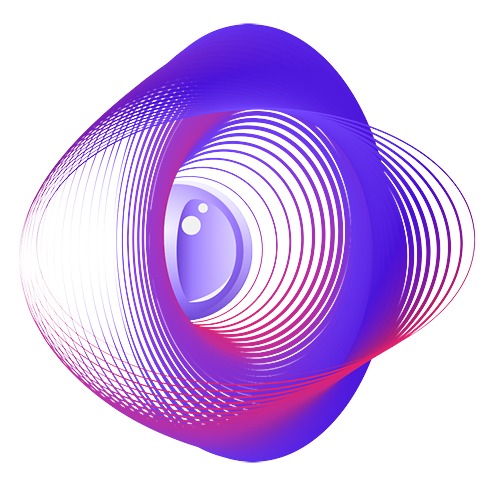

In [1]:
from IPython.display import Image

Image(filename="pl.png", width=200)

In [2]:
# Install additional requirements for this notebook
%pip install -r requirements.txt -q

Note: you may need to restart the kernel to use updated packages.


## Step 1: Serve the JAX-CFD Tesseract


The `cfd-tesseract` is a differentiable Navier-Stokes solver based on [JAX-CFD](https://github.com/google/jax-cfd), wrapped as a Tesseract. Its `apply` function takes an initial velocity field and simulation parameters, then integrates the semi-implicit Navier-Stokes equations forward in time.

Here is the `apply` function, as defined in `cfd_tesseract/tesseract_api.py`:

```python
def cfd_fwd(
    v0: jnp.ndarray,
    density: float,
    viscosity: float,
    inner_steps: int,
    outer_steps: int,
    max_velocity: float,
    cfl_safety_factor: float,
    domain_size_x: float,
    domain_size_y: float,
) -> tuple[jax.Array, jax.Array]:
    """Compute the final velocity field using the semi-implicit Navier-Stokes equations.

    Args:
        v0: Initial velocity field.
        density: Density of the fluid.
        viscosity: Viscosity of the fluid.
        inner_steps: Number of solver steps for each timestep.
        outer_steps: Number of timesteps steps.
        max_velocity: Maximum velocity.
        cfl_safety_factor: CFL safety factor.
        domain_size_x: Domain size in x direction.
        domain_size_y: Domain size in y direction.

    Returns:
        Final velocity field.
    """
    ...
```


We serve the Tesseract from its own process with `Tesseract.from_source`, which builds an isolated environment for it from `cfd-tesseract/tesseract_requirements.txt` on first use.


Next, we start the server using the Tesseract Python SDK. This gives us a running Tesseract instance we can call from Python.


In [3]:
from tesseract_core import Tesseract

cfd_tesseract = Tesseract.from_source("cfd-tesseract/tesseract_api.py")
cfd_tesseract.serve()

## Step 2: Test a forward evaluation with Tesseract-JAX

Before optimizing, let's verify the Tesseract works by running a single forward evaluation. We set up the simulation parameters -- a $64 \times 64$ grid with periodic boundary conditions -- and generate a random initial velocity field. The `apply_tesseract` function from [tesseract-jax](https://github.com/pasteurlabs/tesseract-jax) makes the Tesseract callable as a JAX-compatible function, which is essential for later gradient computation.


In [4]:
# Import necessary libraries
import jax
import jax.numpy as jnp
import jax_cfd.base as cfd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import animation
from PIL import Image as PILImage
from scipy.optimize import minimize
from tesseract_jax import apply_tesseract
from tqdm import tqdm

# Set up the CFD simulation parameters
seed = 0
size = 64
max_velocity = 3.0
domain_size_x = jnp.pi * 2
domain_size_y = jnp.pi * 2

bc = cfd.boundaries.HomogeneousBoundaryConditions(
    (
        (cfd.boundaries.BCType.PERIODIC, cfd.boundaries.BCType.PERIODIC),
        (cfd.boundaries.BCType.PERIODIC, cfd.boundaries.BCType.PERIODIC),
    )
)

grid = cfd.grids.Grid((size, size), domain=((0, domain_size_x), (0, domain_size_y)))
v0 = cfd.initial_conditions.filtered_velocity_field(
    jax.random.PRNGKey(seed), grid, max_velocity
)
vx, vy = v0

params = {
    "density": 1.0,
    "viscosity": 0.01,
    "inner_steps": 25,
    "outer_steps": 30,
    "max_velocity": max_velocity,
    "cfl_safety_factor": 0.5,
    "domain_size_x": domain_size_x,
    "domain_size_y": domain_size_y,
}

# Define initial velocity field
v0 = np.stack([np.array(vx.array.data), np.array(vy.array.data)], axis=-1)


# Define the Tesseract function
def cfd_tesseract_fn(v0):
    return apply_tesseract(cfd_tesseract, inputs=dict(v0=v0, **params))


# Apply Tesseract to the initial velocity field
outputs = cfd_tesseract_fn(v0)

Using the forward pass output, we visualize the $x$ and $y$ components of the final velocity field as heatmaps. This confirms the simulation is producing physically reasonable flow patterns.


Text(0.5, 1.0, 'vy')

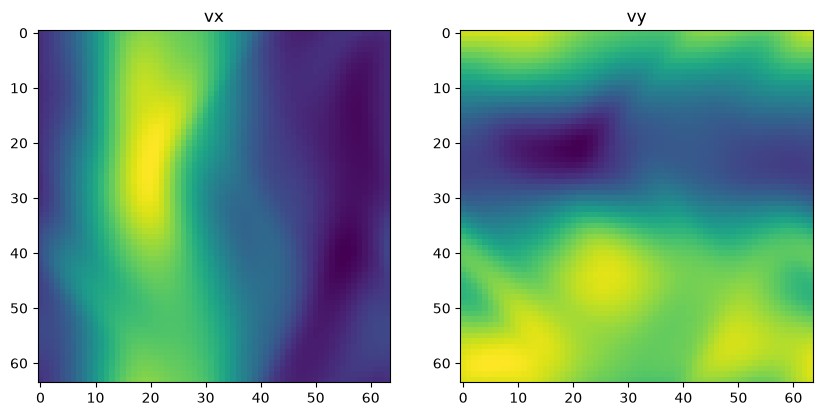

In [5]:
vxn = outputs["result"][..., 0]
vyn = outputs["result"][..., 1]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(vxn, cmap="viridis")
ax[0].set_title("vx")
ax[1].imshow(vyn, cmap="viridis")
ax[1].set_title("vy")

Next we define a vorticity function for later use (recalling that vorticity is the curl of the flow velocity, *ie.* $\omega = \nabla \times \mathbf{v}$).

In [6]:
def vorticity(vxn, vyn):
    vxn = cfd.grids.GridArray(vxn, grid=grid, offset=(1.0, 0.5))
    vyn = cfd.grids.GridArray(vyn, grid=grid, offset=(0.5, 1.0))

    # reconstrut GridVariable from input
    vxn = cfd.grids.GridVariable(vxn, bc)
    vyn = cfd.grids.GridVariable(vyn, bc)

    # differntiate
    _, dvx_dy = cfd.finite_differences.central_difference(vxn)
    dvy_dx, _ = cfd.finite_differences.central_difference(vyn)

    return dvy_dx.data - dvx_dy.data

## Step 3: Optimize the initial state via gradient descent

Now we perform the core task: finding an initial velocity field $v_0$ such that the vorticity of the final state $v_N$ resembles a target image. This is a high-dimensional optimization problem -- the decision variable is the entire $64 \times 64 \times 2$ velocity field (8,192 parameters). Without gradients, this would be intractable.

Let's start by loading the target image.


Text(0.5, 1.0, 'Target vorticity')

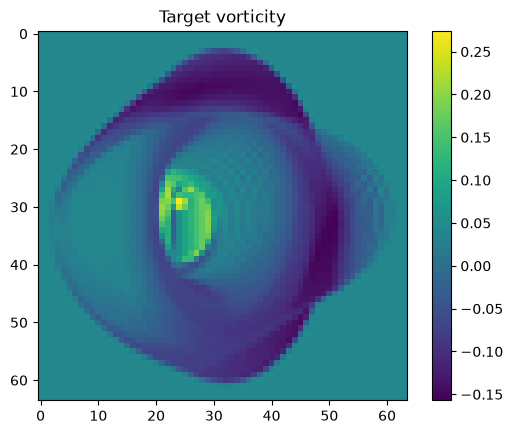

In [7]:
img = plt.imread("pl.png")
img = img.mean(axis=-1)
img = PILImage.fromarray((img * 255).astype(np.uint8))
img_shape_y, img_shape_x = img.size

img = img.resize((size, size))
img = np.array(img).astype(np.float32) / 255.0

# normalize around 0
img = img - img.mean()

plt.imshow(img, cmap="viridis")
plt.colorbar()
plt.title("Target vorticity")

We define the loss function as the mean squared error between the simulated vorticity and the target image. To ensure physical realism, we add a penalty on the divergence of the initial velocity field -- for an incompressible flow, $\nabla \cdot \mathbf{v} = 0$. This acts as a soft constraint:

$$
\mathcal{L}(v_0) = \text{MSE}(\omega(v_N), \omega_{\text{target}}) + 0.05 \cdot \text{MSE}(\nabla \cdot v_0, 0)
$$

where $\omega = \nabla \times \mathbf{v}$ is the vorticity.


In [8]:
def mse(x, y):
    return jnp.mean((x - y) ** 2)


def divergence(vxn, vyn):
    vxn = cfd.grids.GridArray(vxn, grid=grid, offset=(1.0, 0.5))
    vyn = cfd.grids.GridArray(vyn, grid=grid, offset=(0.5, 1.0))

    # reconstruct GridVariable from input
    vxn = cfd.grids.GridVariable(vxn, bc)
    vyn = cfd.grids.GridVariable(vyn, bc)

    return cfd.finite_differences.divergence([vxn, vyn]).data


def loss_fn(v0_flat, target=img, xlen=grid.shape[0]):
    total_len = len(v0_flat)
    ylen = (total_len // 2) // xlen
    v0x = v0_flat[: total_len // 2].reshape(xlen, ylen)
    v0y = v0_flat[total_len // 2 :].reshape(xlen, ylen)

    div = divergence(v0x, v0y)

    vn = cfd_tesseract_fn(v0=jnp.stack([v0x, v0y], axis=-1))["result"]

    vxn = vn[..., 0]
    vyn = vn[..., 1]

    vort = vorticity(vxn, vyn)

    # add divergence penalty term to ensure the field is divergence free
    return mse(vort, target) + 0.05 * mse(div, 0.0)

We use the L-BFGS-B optimizer from `scipy.optimize.minimize` to find the optimal initial velocity field. Because `apply_tesseract` makes the Tesseract a native JAX operation, `jax.value_and_grad` can differentiate through the entire CFD simulation automatically. This is the key advantage -- no hand-coded adjoint solver is needed.

Executing this cell can take a few minutes.


In [9]:
v0_field = cfd.initial_conditions.filtered_velocity_field(
    jax.random.PRNGKey(221), grid, max_velocity
)
v0_flat = np.array([vx.array.data, vy.array.data]).flatten()
grad_fn = jax.jit(jax.value_and_grad(loss_fn))

max_iter = 400
with tqdm(total=max_iter) as pbar:
    i = 0

    def callback(intermediate_result):
        global i
        i += 1
        pbar.set_postfix(loss=f"{intermediate_result.fun:.4f}")
        pbar.update(1)

    opt = minimize(
        grad_fn,
        v0_flat,
        method="L-BFGS-B",
        jac=True,
        callback=callback,
        options={"maxiter": max_iter},
    )

print(f"Optimisation converged after {i} iterations")

 26%|██▌       | 102/400 [02:11<06:23,  1.29s/it, loss=0.0007]

Optimisation converged after 102 iterations


## Step 4: Visualize the optimized flow

To see how the optimized initial condition evolves over time, we step through the simulation one outer step at a time and record the vorticity at each frame. This produces an animation showing the fluid flow gradually forming the target image.


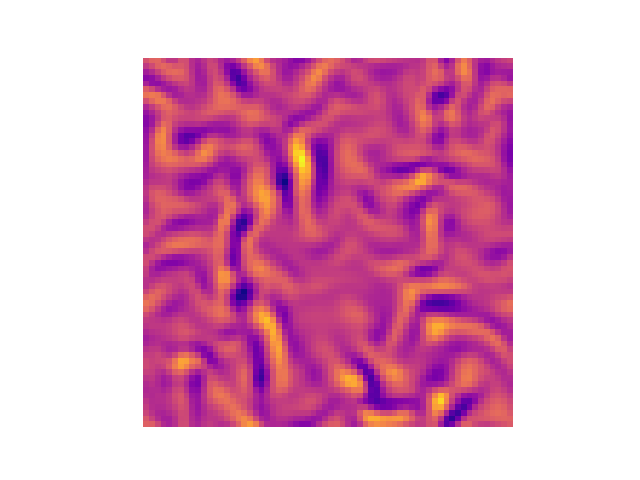

In [10]:
v0_flat = opt.x
xlen = grid.shape[0]
ylen = grid.shape[1]
v0x = v0_flat[: xlen * ylen].reshape(xlen, ylen)
v0y = v0_flat[xlen * ylen :].reshape(xlen, ylen)
v0 = jnp.stack([v0x, v0y], axis=-1)

trajectory = []
vi = v0.copy()

params_2 = params.copy()
params_2.update({"outer_steps": 1})


# NOTE: We intentionally redefine cfd_tesseract_fn here with outer_steps=1
# (instead of 30) so we can capture intermediate frames for the animation.
# The original definition used params with outer_steps=30 for optimization.
def cfd_tesseract_fn(v0):
    res = apply_tesseract(cfd_tesseract, inputs=dict(v0=v0, **params_2))
    return res["result"]


for _ in range(30):
    vi = cfd_tesseract_fn(vi)

    vxn = vi[..., 0]
    vyn = vi[..., 1]

    vort = vorticity(vxn, vyn)

    trajectory.append(vort)

# repeat last frame a few times
trajectory.extend([vort] * 10)


fig = plt.figure()

ims = []
for vort in trajectory:
    im = plt.imshow(vort, cmap="plasma", animated=True)
    # remove axis
    plt.axis("off")
    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=100, blit=True, repeat_delay=1000)
plt.close(fig)

ani.save("/tmp/vorticity.gif", writer="pillow", fps=10)
Image(filename="/tmp/vorticity.gif", embed=True)

## Takeaways

In this tutorial, we optimized the initial conditions of a 2D Navier-Stokes simulation so that the resulting vorticity field matches a target image. Here are the key points:

1. **Differentiable simulation via Tesseract.** By wrapping JAX-CFD in a Tesseract, we obtained a self-contained, differentiable CFD solver. The `apply_tesseract` function from tesseract-jax makes it seamlessly callable from JAX, with full gradient support.

2. **High-dimensional optimization made tractable.** The initial velocity field has 8,192 parameters. Gradient-based optimization (L-BFGS-B) converged in ~100 iterations -- this would be infeasible with gradient-free methods.

3. **No hand-coded adjoints.** The gradients flow automatically through the Tesseract's JAX-based `apply` function. Adding new physics or changing the objective requires no manual derivative implementation.

4. **Composability.** The same Tesseract could be reused in other contexts -- Bayesian inference, design optimization, or as a component in a larger differentiable pipeline -- without any changes to the Tesseract itself.


In [11]:
# Tear down Tesseract after use to prevent resource leaks
cfd_tesseract.teardown()